In [ ]:
# Customer Segmentation Analysis
# The aim of this data analytics project is to perform customer segmentation analysis for an e-
# commerce company. By analyzing customer behavior and purchase patterns, the goal is to
# group customers into distinct segments. This segmentation can inform targeted marketing
# strategies, improve customer satisfaction, and enhance overall business strategies.

In [2]:
# import libraries to use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# load csv file
from google.colab import files
uploaded = files.upload()

Saving ifood_df.csv to ifood_df.csv


In [5]:
df = pd.read_csv('ifood_df.csv')
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [6]:
df.shape

(2205, 39)

In [7]:
# Data Collection: Obtain a dataset containing customer information, purchase history, and relevant data.
df.describe()


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [8]:
df.columns.tolist() #checks cols name

['Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response',
 'Age',
 'Customer_Days',
 'marital_Divorced',
 'marital_Married',
 'marital_Single',
 'marital_Together',
 'marital_Widow',
 'education_2n Cycle',
 'education_Basic',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'MntTotal',
 'MntRegularProds',
 'AcceptedCmpOverall']

In [9]:
# Data Exploration and Cleaning:
#  Explore the dataset, understand its structure, and handle any missing or inconsistent data.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [10]:
df.isnull().sum()
# Observation -> No missing Values found

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [11]:
df.duplicated().sum() #checks duplicate -> 184 values were duplicate

np.int64(184)

In [12]:
df.drop_duplicates(inplace=True) #remove duplicates

In [13]:
df.duplicated().sum() # hence duplicate values are deleted

np.int64(0)

In [14]:
df.dtypes

,0
Income,float64
Kidhome,int64
Teenhome,int64
Recency,int64
MntWines,int64
MntFruits,int64
MntMeatProducts,int64
MntFishProducts,int64
MntSweetProducts,int64
MntGoldProds,int64


In [15]:
# Descriptive Statistics:
# Calculate key metrics such as average purchase value, frequency of purchases, etc.
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,...,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,0.443345,0.509649,48.880752,306.492331,26.364671,166.059871,37.603662,27.268679,43.921821,...,0.251856,0.034636,0.090549,0.024245,0.502227,0.165760,0.217219,563.789213,519.867392,0.302326
std,20713.046401,0.536196,0.546393,28.950917,337.603877,39.776518,219.869126,54.892196,41.575454,51.678211,...,0.434186,0.182902,0.287038,0.153848,0.500119,0.371957,0.412455,576.775749,554.797857,0.680812
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.000000
25%,35416.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,42.000000,0.000000
50%,51412.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.000000
75%,68274.000000,1.000000,1.000000,74.000000,507.000000,33.000000,230.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,883.000000,0.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000


In [16]:
df['Income'].mean() #Average Customer Income

np.float64(51687.2587827808)

In [17]:
df['MntTotal'].mean() #Avg Customer spending

np.float64(563.789213260762)

In [18]:
df['Recency'].mean()  #Average Recency

np.float64(48.880752102919345)

In [19]:
# Average Purchases
df['TotalPurchases'] = (df['NumWebPurchases']+df['NumCatalogPurchases']+ df['NumStorePurchases'])
df['TotalPurchases'].mean()

np.float64(12.567540821375557)

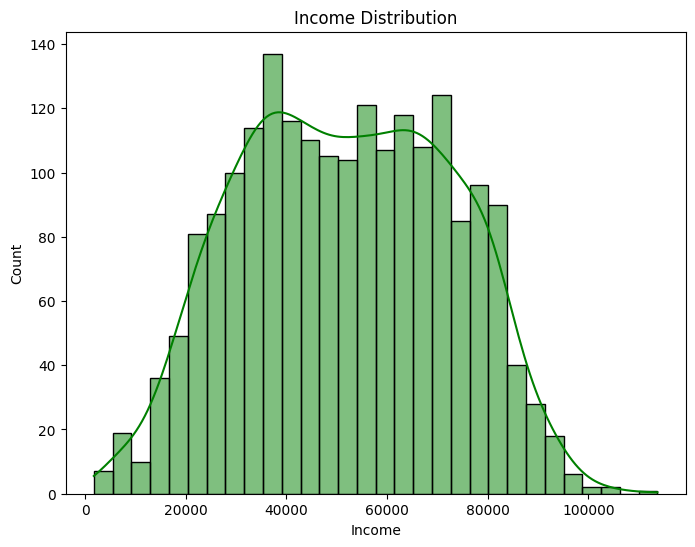

In [20]:
# Exploratory Data Analysis
# income distribution

plt.figure(figsize=(8,6))
sns.histplot(df['Income'], bins=30,kde = True, color = 'green')
plt.title("Income Distribution")
plt.show()

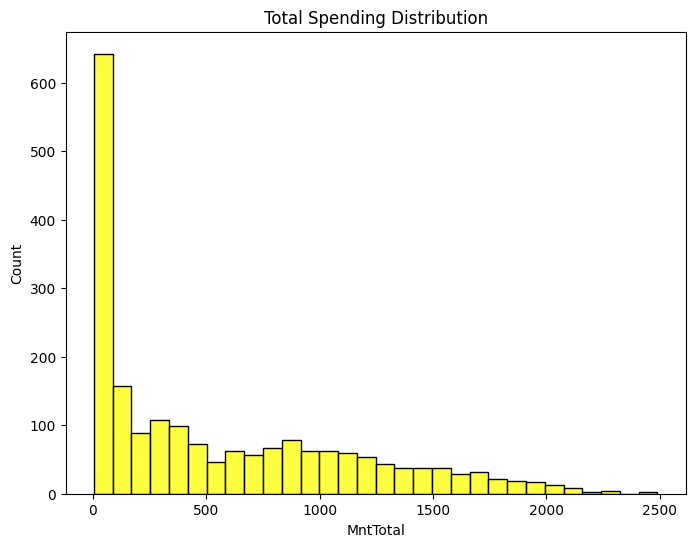

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(df['MntTotal'], bins=30, color = 'yellow')
plt.title("Total Spending Distribution")
plt.show()

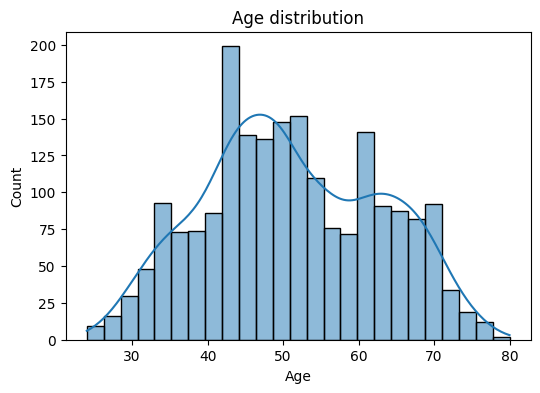

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins= 25,kde = True)
plt.title('Age distribution')
plt.show()

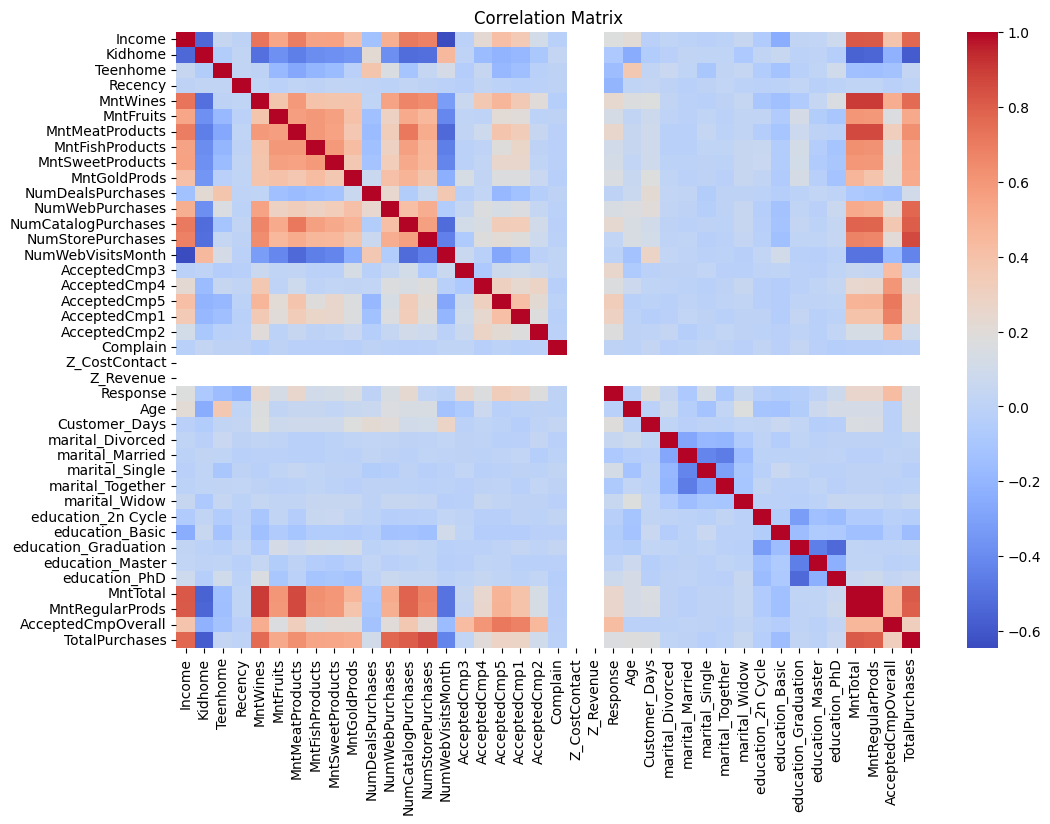

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),cmap ='coolwarm', annot = False)
plt.title('Correlation Matrix')
plt.show()

In [29]:
# Feature Selection for Segmentation
features = df[[
    'Income',
    'Kidhome',
    'Teenhome',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Recency',
    'TotalPurchases'
]]

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

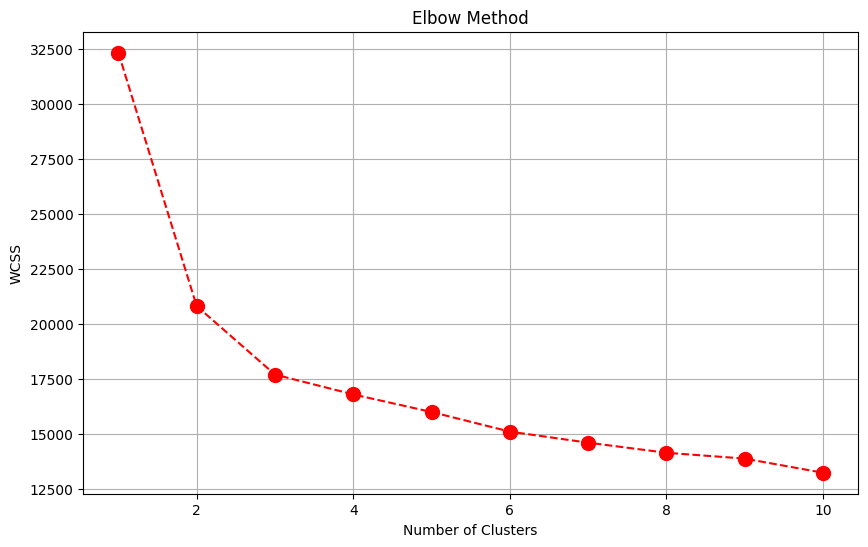

In [34]:
from sklearn.cluster import KMeans
# ind Optimal Number of Clusters
# elbow method
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(scaled_features)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(10,6))
plt.plot(range(1,11), wcss, marker='o', linestyle='--', color = 'red', markersize=10)
plt.grid(True)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()
# Report Observation
# Usually elbow appears around 4 or 5 clusters.

In [36]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)
df['Cluster'].value_counts()

,count
Cluster,
0,830
2,437
3,417
1,337


In [37]:
# Evaluate Clustering
from sklearn.metrics import silhouette_score
score = silhouette_score(scaled_features, df['Cluster'])
print(f'Silhouette Score: {score}')

Silhouette Score: 0.20238871757665244


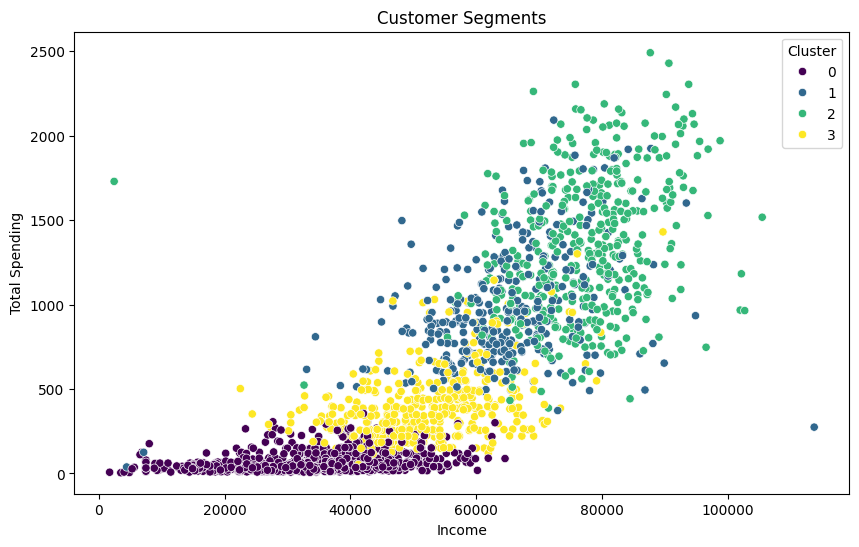

In [40]:
# Visualize Customer Segments
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Income', y='MntTotal', hue='Cluster', palette='viridis')
plt.title('Customer Segments')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.show()

/tmp/ipykernel_2580/719835090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Cluster', y='MntTotal', palette='viridis')


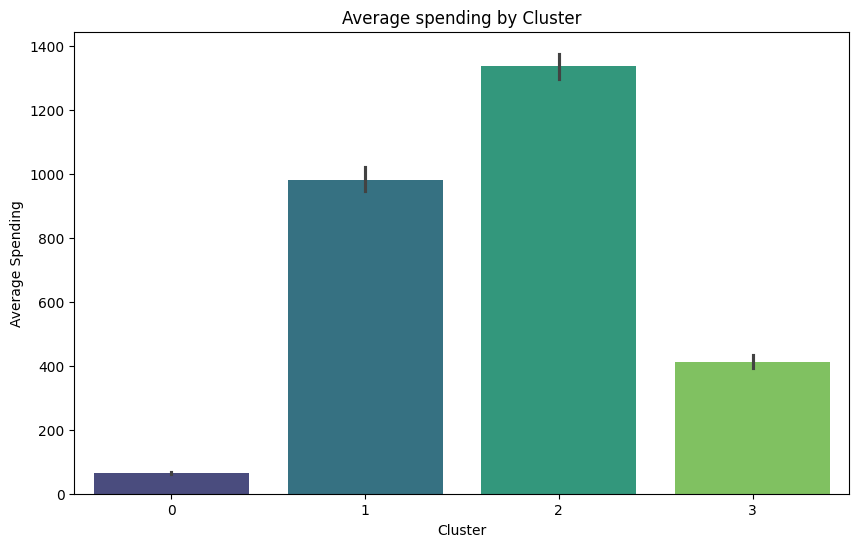

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Cluster', y='MntTotal', palette='viridis')
plt.xlabel('Cluster')
plt.ylabel('Average Spending')
plt.title('Average spending by Cluster')
plt.show()

In [45]:
# Segment Analysis
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Age',
    'MntTotal',
    'TotalPurchases'
]].mean()
cluster_summary

,Income,Age,MntTotal,TotalPurchases
Cluster,,,,
0,32702.144578,47.777108,64.284337,5.378313
1,64646.501484,54.531157,981.089021,20.887240
2,77033.496568,51.743707,1335.491991,19.144165
3,52440.434053,54.350120,412.050360,13.261391


In [46]:
cluster_summary.round(2)

,Income,Age,MntTotal,TotalPurchases
Cluster,,,,
0,32702.14,47.78,64.28,5.38
1,64646.50,54.53,981.09,20.89
2,77033.50,51.74,1335.49,19.14
3,52440.43,54.35,412.05,13.26


In [ ]:
# Insights & Recommendations
# Cluster 0 - High Value Customers
# High income
# High spending
# Frequent purchases

# Recommendation:
# VIP membership
# Exclusive offers
# Loyalty rewards

# Cluster 1 - Budget Customers
# Lower income
# Low spending

# Recommendation:
# Discount campaigns
# Seasonal promotions

# Cluster 2 - Potential Customers
# High income
# Moderate spending

# Recommendation:

# Personalized recommendations
# Upselling opportunities

# Cluster 3 - Occasional Buyers
# Infrequent purchases
# Moderate spending

# Recommendation:

# Retargeting campaigns
# Email marketing

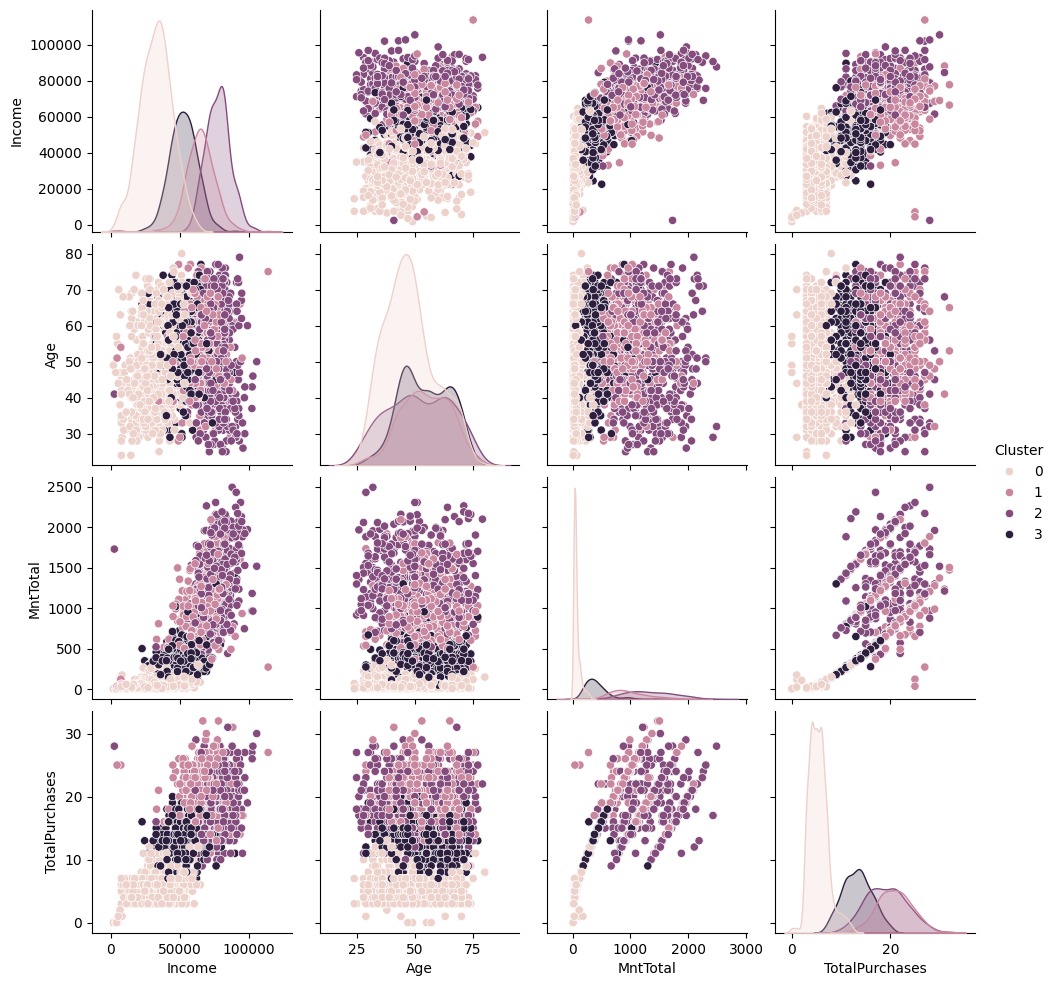

In [47]:
sns.pairplot(
    df[
        [
            'Income',
            'Age',
            'MntTotal',
            'TotalPurchases',
            'Cluster'
        ]
    ],
    hue='Cluster'
)

plt.show()

In [ ]:
# Customer Segmentation Results
# The K-Means clustering algorithm successfully segmented customers into 4 distinct groups based on income, spending behavior, purchase frequency, and recency.
# The scatter plot of Income vs Total Spending clearly shows separate customer groups with different purchasing behaviors.

In [ ]:
# Segment Analysis
# Cluster 0 - Low Value Customers
# Characteristics
# Lowest spending among all clusters
# Low to medium income
# Infrequent purchases
# Limited engagement with products
# Evidence

# From the bar chart:
# Average Spending ≈ 70
# This is the lowest spending segment.

# Business Recommendation
# Offer discount coupons
# Run promotional campaigns
# Send personalized offers
# Encourage first-time and repeat purchases

# Cluster 1 - High Value Customers
# Characteristics
# High income
# High spending
# Frequent purchases
# Strong customer engagement
# Evidence
# Average Spending ≈ 980

# These customers generate significant revenue.

# Business Recommendation
# Introduce loyalty programs
# Provide premium memberships
# Offer exclusive product launches
# Prioritize customer retention
# Cluster 2 - Premium Customers
# Characteristics
# Highest income levels
# Highest spending levels
# Most profitable customer group
# Evidence
# Average Spending ≈ 1330

# This cluster has the highest average spending across all segments.

# Business Recommendation
# VIP rewards program
# Personalized recommendations
# Premium product bundles
# Early access to new products

# This is the most valuable customer segment.

# Cluster 3 – Moderate Customers
# Characteristics
# Moderate income
# Moderate spending
# Potential for growth
# Evidence
# Average Spending ≈ 410

# These customers spend more than Cluster 0 but significantly less than Clusters 1 and 2.

# Business Recommendation
# Upselling strategies
# Product recommendations
# Targeted email campaigns
# Seasonal offers

# Key Findings
# 1. Strong Relationship Between Income and Spending

# The scatter plot demonstrates a positive relationship between customer income and total spending.
# Observation: Customers with higher incomes tend to spend more on products.

# 2. Premium Customers Drive Revenue

# Clusters 1 and 2 account for the majority of high-spending customers.
# Business Impact: Retaining these customers should be a top priority.

# 3. Large Low-Spending Segment Exists

# Cluster 0 contains customers with very low spending levels.
# Business Opportunity: Convert these customers into active buyers through marketing campaigns.

# 4. Growth Potential in Moderate Customers
# Cluster 3 represents customers who already engage with the business but have room to increase spending.
# Business Opportunity: Cross-selling and upselling campaigns can increase revenue from this segment.

# Final Conclusion
# The customer segmentation analysis successfully identified four distinct customer groups using K-Means clustering.
# The results reveal clear differences in income and purchasing behavior across customer segments.
# Premium customers (Cluster 2) and high-value customers (Cluster 1) contribute the highest revenue and should be targeted through loyalty and retention programs.
# Moderate customers (Cluster 3) present growth opportunities, while low-value customers (Cluster 0) can be activated through promotional strategies. T
# hese insights can help businesses improve customer targeting, optimize marketing campaigns, and maximize overall profitability.